# Análisis RETC/SINADER — Destinatario Final y Generación Industrial (RCD, RM)
**Regemac S.A. · Informe 1 · ICS3913/ICS3013**

Este cuaderno reemplaza al notebook exploratorio anterior. Los cambios principales:

- Lee las bases **ya estandarizadas** (mismo esquema de columnas y mismo formato de archivo en todos los años), no las bases crudas del RETC con separadores, codificaciones y nombres de columna distintos año a año.
- Incorpora **Generación Industrial (2014-2024)**, además de Destinatario Final (2021-2024), lo que permite mirar el mercado desde el lado del generador (quién declara haber enviado el residuo) y no solo desde el destinatario.
- La metodología de la sección 3 se validó contra la auditoría de Pedro (`Anexo_REGEMAC_revision_final.pdf`, `Resumen_competencia_REGEMAC_revision_final.pdf`): los totales anuales calculados aquí coinciden con los de su Enfoque A (diferencias menores a 0,1%; ver también la sección 14, que reproduce sus parámetros exactos con nuestras fuentes).
- Incluye 4 mapas geográficos (destinatarios, generadores y flujos entre ambos, sección 15) con un encuadre fijo compartido para poder compararlos entre sí.
- **Ojo:** este cuaderno *no* incluye la estimación de volumen a partir de los reportes de envío internos de Regemac — esa sección dependía del archivo de envíos que se usó en el notebook anterior y no está disponible en esta sesión. Si quieres esa parte de vuelta, vuelve a subir ese archivo y se agrega.

**Flujo de tratamiento declarado (RCD-RM, último año disponible)** — vista previa estática de los diagramas de Sankey interactivos de la sección 10:

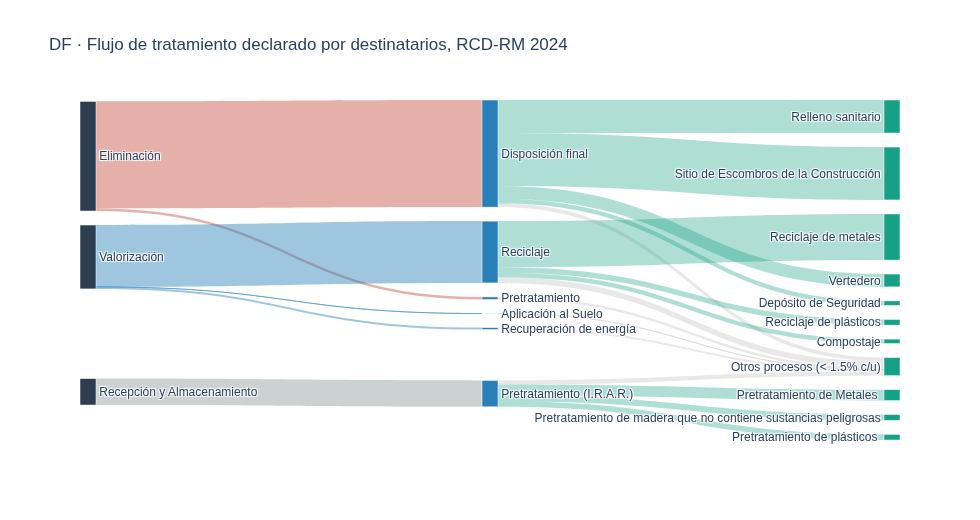

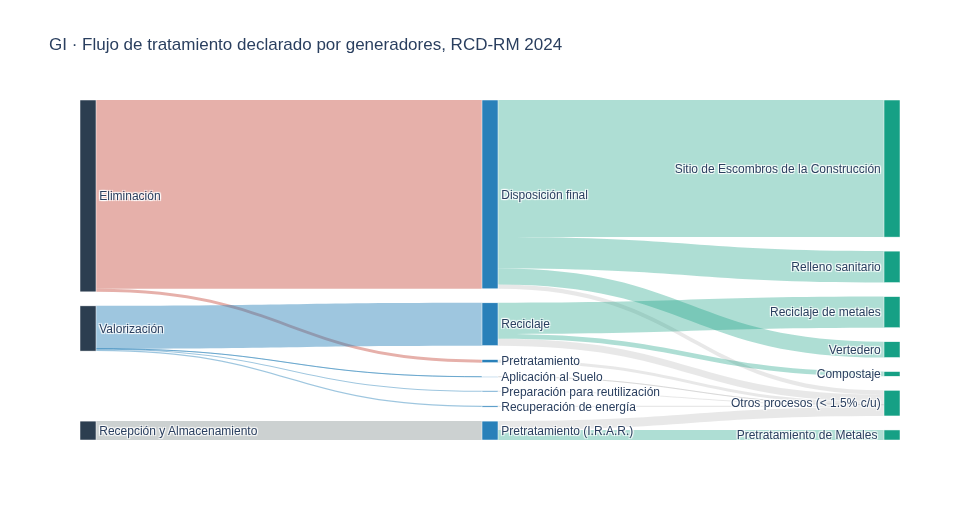


## 1. Carga de datos

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

GITHUB_BASE = "https://raw.githubusercontent.com/fernando25132/Evalpro/refs/heads/main"

DF_FILES = [
    "data/Destinatario_Final/df-sinader-2021-estandarizado.csv",
    "data/Destinatario_Final/df-sinader-2022-estandarizado.csv",
    "data/Destinatario_Final/df-sinader-2023-estandarizado.csv",
    "data/Destinatario_Final/df-sinader-2024-estandarizado_Parte1.csv",
    "data/Destinatario_Final/df-sinader-2024-estandarizado_Parte2.csv",
]

GI_FILES = [
    "data/Generacion_Industrial/gi-sinader-2014-estandarizado.csv",
    "data/Generacion_Industrial/gi-sinader-2015-estandarizado.csv",
    "data/Generacion_Industrial/gi-sinader-2016-estandarizado_Parte1.csv",
    "data/Generacion_Industrial/gi-sinader-2016-estandarizado_Parte2.csv",
    "data/Generacion_Industrial/gi-sinader-2017-estandarizado_Parte1.csv",
    "data/Generacion_Industrial/gi-sinader-2017-estandarizado_Parte2.csv",
    "data/Generacion_Industrial/gi-sinader-2017-estandarizado_Parte3.csv",
    "data/Generacion_Industrial/gi-sinader-2018-estandarizado_Parte1.csv",
    "data/Generacion_Industrial/gi-sinader-2018-estandarizado_Parte2.csv",
    "data/Generacion_Industrial/gi-sinader-2018-estandarizado_Parte3.csv",
    "data/Generacion_Industrial/gi-sinader-2018-estandarizado_Parte4.csv",
    "data/Generacion_Industrial/gi-sinader-2019-estandarizado_Parte1.csv",
    "data/Generacion_Industrial/gi-sinader-2019-estandarizado_Parte2.csv",
    "data/Generacion_Industrial/gi-sinader-2020-estandarizado_Parte1.csv",
    "data/Generacion_Industrial/gi-sinader-2020-estandarizado_Parte2.csv",
    "data/Generacion_Industrial/gi-sinader-2021-estandarizado_Parte1.csv",
    "data/Generacion_Industrial/gi-sinader-2021-estandarizado_Parte2.csv",
    "data/Generacion_Industrial/gi-sinader-2022-estandarizado_Parte1.csv",
    "data/Generacion_Industrial/gi-sinader-2022-estandarizado_Parte2.csv",
    "data/Generacion_Industrial/gi-sinader-2023-estandarizado_Parte1.csv",
    "data/Generacion_Industrial/gi-sinader-2023-estandarizado_Parte2.csv",
] + [f"data/Generacion_Industrial/gi-sinader-2024-estandarizado_Parte{i}.csv" for i in range(1, 13)]

def cargar_estandarizado(rutas_relativas, base=GITHUB_BASE):
    # Lee y concatena archivos ya estandarizados (mismo separador/encoding en todos: coma, utf-8-sig).
    partes = [pd.read_csv(f"{base}/{r}", encoding='utf-8-sig', low_memory=False) for r in rutas_relativas]
    return pd.concat(partes, ignore_index=True)

df_all = cargar_estandarizado(DF_FILES)
gi_all = cargar_estandarizado(GI_FILES)

print(f"Destinatario Final: {len(df_all):,} filas, años {sorted(df_all['anio'].unique())}")
print(f"Generación Industrial: {len(gi_all):,} filas, años {sorted(gi_all['anio'].unique())}")


## 2. Filtro RM + RCD (LER capítulo 17)

Algunos años (DF 2023; GI 2022-2023) traen la columna numérica `ler_capitulo_num` vacía — el número solo quedó en el texto de `ler_capitulo` (ej. `"17 | Residuos de la construcción y demolición"`). El filtro de abajo usa el número cuando existe y si no, lo extrae del texto, para no perder esos años silenciosamente.

In [ ]:
def cap17_mask(df):
    num = pd.to_numeric(df['ler_capitulo_num'], errors='coerce')
    txt_num = pd.to_numeric(df['ler_capitulo'].astype(str).str.extract(r'^(\d+)')[0], errors='coerce')
    return num.fillna(txt_num) == 17

def filtro_rm_rcd_destinatario(df, solo_entrada=True):
    # RM + RCD desde el lado del DESTINATARIO (región del establecimiento receptor).
    m = df['region'].astype(str).str.contains('Metropolitana', na=False) & cap17_mask(df)
    if solo_entrada and 'tipo_movimiento' in df.columns:
        m &= pd.to_numeric(df['tipo_movimiento'], errors='coerce') == 1
    return df[m].copy()

def filtro_rm_rcd_generador(df):
    # RM + RCD desde el lado del GENERADOR, mirando a qué región va el destinatario declarado (trazabilidad).
    m = df['trazabilidad_region'].astype(str).str.contains('Metropolitana', na=False) & cap17_mask(df)
    return df[m].copy()

df_rm = filtro_rm_rcd_destinatario(df_all)
gi_rm = filtro_rm_rcd_generador(gi_all)
print(f"DF, RM+RCD (entrada): {len(df_rm):,} filas")
print(f"GI, RM+RCD (por trazabilidad al destinatario): {len(gi_rm):,} filas")


## 3. Validación: ¿coincide con la auditoría de Pedro?

La tabla "Enfoque A" del anexo de Pedro (región del establecimiento, LER 17, `tipo_recepcion = 1`, agrupado por RUT) da estos totales:

| Año | Toneladas | Empresas | Variación |
|---|---|---|---|
| 2021 | 211.117,3 | 12 | — |
| 2022 | 431.826,6 | 32 | +104,54% |
| 2023 | 416.657,8 | 44 | -3,51% |
| 2024 | 951.025,7 | 73 | +128,25% |

Si la tabla de abajo da (casi) los mismos números, confirma que el filtro y la base estandarizada están bien construidos.

In [ ]:
tabla_anual = (df_rm.groupby('anio')
               .agg(toneladas=('toneladas', 'sum'), empresas=('rut', 'nunique'))
               .reset_index())
tabla_anual['variacion_%'] = tabla_anual['toneladas'].pct_change() * 100
tabla_anual['toneladas'] = tabla_anual['toneladas'].round(1)
tabla_anual['variacion_%'] = tabla_anual['variacion_%'].round(2)
tabla_anual


## 4. Nombres de empresas (usado en el resto del cuaderno)

In [ ]:
MAPA_EMPRESAS = [
    (r'REGENERADORA DE MATERIALES', 'Regemac'),
    (r'INVERSIONES CORMI', 'Inversiones Cormi'),
    (r'(INDUSTRIAL Y )?MINERA LOS ESTEROS', 'Ind. y Minera Los Esteros'),
    (r'SERVICIO MECANIZADO', 'Servicio Mecanizado Mov. Tierra'),
    (r'BALTIERRA', 'Inmobiliaria Baltierra'),
    (r'SOC(IEDAD)? P[EÉ]TREOS', 'Soc. Pétreos'),
    (r'CRUZ Y MELLADO', 'Cruz y Mellado'),
]

def nombre_normalizado(razon_social):
    rs = str(razon_social).upper()
    for patron, nombre in MAPA_EMPRESAS:
        if re.search(patron, rs):
            return nombre
    return 'Otras empresas'

def nombre_corto_empresa(razon_social, max_len=38):
    # Para etiquetas de gráfico: nombre en Title Case, truncado si es muy largo.
    n = str(razon_social).title()
    reemplazos = {' S A': ' S.A.', ' Sa': ' S.A.', ' Spa': ' SpA', ' Ltda': ' Ltda.', ' Limitada': ' Ltda.'}
    for k, v in reemplazos.items():
        if n.endswith(k):
            n = n[: -len(k)] + v
    return n if len(n) <= max_len else n[: max_len - 3] + "..."

def nombre_corto_material(ler_nombre, max_len=42):
    # 'ler_nombre' viene como "CODIGO | Descripción larga" -> nos quedamos solo con la descripción, truncada.
    texto = str(ler_nombre)
    if '|' in texto:
        texto = texto.split('|', 1)[1].strip()
    return texto if len(texto) <= max_len else texto[: max_len - 3] + "..."

ORDEN_EMPRESAS = ['Regemac', 'Inversiones Cormi', 'Ind. y Minera Los Esteros',
                   'Servicio Mecanizado Mov. Tierra', 'Inmobiliaria Baltierra',
                   'Soc. Pétreos', 'Cruz y Mellado', 'Otras empresas']

# Paleta fija por empresa (se reutiliza en todos los gráficos para que los colores signifiquen lo mismo siempre)
COLOR_EMPRESA = {
    'Regemac': '#c0392b',
    'Inversiones Cormi': '#2980b9',
    'Ind. y Minera Los Esteros': '#27ae60',
    'Servicio Mecanizado Mov. Tierra': '#8e44ad',
    'Inmobiliaria Baltierra': '#e91e8c',
    'Soc. Pétreos': '#16a085',
    'Cruz y Mellado': '#7f8c8d',
    'Otras empresas': '#95a5a6',
}

df_rm['empresa'] = df_rm['razon_social'].apply(nombre_normalizado)
gi_rm = gi_rm.copy()
gi_rm['empresa'] = gi_rm['trazabilidad_razon_social'].apply(nombre_normalizado)


## 5. Participación de mercado 2014-2024 y gráfico de líneas (Regemac destacado)

Fuente: GI, vía trazabilidad al destinatario (es la única base que cubre 2014-2024 completo). El eje derecho muestra el tonelaje **total del mercado RM+RCD ese año** — con eso puedes convertir cualquier % del eje izquierdo a toneladas aproximadas (toneladas de una empresa ≈ % × total del año). No se puso un eje derecho "fijo" en toneladas por empresa porque el total del mercado cambia año a año, así que una sola escala no serviría para las ocho series a la vez.

Se generan dos versiones: con "Otras empresas" (gris) incluida, y sin ella — la segunda deja ver mejor las diferencias entre las siete empresas nombradas.

In [ ]:
toneladas_anio_empresa = gi_rm.groupby(['anio', 'empresa'])['toneladas'].sum()
toneladas_anio_total = toneladas_anio_empresa.groupby(level='anio').transform('sum')
participacion = (toneladas_anio_empresa / toneladas_anio_total).reset_index(name='participacion')

pivot_participacion = participacion.pivot(index='anio', columns='empresa', values='participacion').reindex(columns=ORDEN_EMPRESAS).fillna(0)
total_mercado_anio = toneladas_anio_empresa.groupby(level='anio').sum()

def graficar_participacion(incluir_otras=True):
    empresas_mostradas = ORDEN_EMPRESAS if incluir_otras else [e for e in ORDEN_EMPRESAS if e != 'Otras empresas']

    fig, ax = plt.subplots(figsize=(11.5, 6.5))
    ax2 = ax.twinx()
    ax2.fill_between(total_mercado_anio.index, total_mercado_anio.values / 1000, color='#dfe6e9', alpha=0.6, zorder=0, label='Mercado total (eje derecho)')
    ax2.set_ylabel('Toneladas totales del mercado RM+RCD (miles)', color='#7f8c8d')
    ax2.tick_params(axis='y', colors='#7f8c8d')
    ax2.set_ylim(0, total_mercado_anio.max() / 1000 * 1.15)

    for empresa in empresas_mostradas:
        es_regemac = empresa == 'Regemac'
        ax.plot(pivot_participacion.index, pivot_participacion[empresa] * 100,
                marker='o', linewidth=3 if es_regemac else 1.4,
                color=COLOR_EMPRESA[empresa],
                alpha=1.0 if es_regemac else 0.85,
                label=empresa, zorder=6 if es_regemac else 3)

    subtitulo = "con 'Otras empresas'" if incluir_otras else "sin 'Otras empresas'"
    ax.set_title(f"Participación de mercado, RCD-RM ({subtitulo})", fontsize=12, fontweight='bold')
    ax.set_ylabel('Participación de mercado (%)')
    ax.set_xlabel('Año')
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    ax.legend(loc='upper left', bbox_to_anchor=(1.08, 1), fontsize=9)
    ax.axvspan(2016, 2018, alpha=0.08, color='orange')
    ax.text(2017, ax.get_ylim()[1] * 0.95, 'Trazabilidad baja\n(19-47% de las filas)', ha='center', fontsize=8, color='#996600')
    plt.tight_layout()
    plt.show()

graficar_participacion(incluir_otras=True)
graficar_participacion(incluir_otras=False)

pivot_participacion.round(4) * 100


**Nota:** estos números pueden diferir levemente (unos pocos puntos porcentuales) de los que se ven en el documento de análisis anterior del proyecto, porque esa versión aplicó además una corrección manual a un grupo de declaraciones de 2024 mal etiquetadas como región Metropolitana (en realidad Arica). Ese ajuste puntual no está reproducido aquí — si quieres que lo agreguemos, dímelo y lo incorporamos como un paso explícito y documentado en vez de dejarlo implícito.

## 6. Concentración de mercado: destinatarios 2024, DF vs. GI

El mismo listado de "quién concentra el mercado", calculado dos veces con la misma lógica: una desde DF (el destinatario se autodeclara) y otra desde GI (el generador declara a quién le envió, vía trazabilidad). El título de cada gráfico dice cuántas empresas hay realmente en el top (por si en algún año hay menos de 10 destinatarios distintos).

In [ ]:
def grafico_top_destinatarios(df, columna_empresa_real, anio, fuente_nombre, color_base, n=10):
    sub = df[df['anio'] == anio]
    tonelaje = sub.groupby(columna_empresa_real)['toneladas'].sum().sort_values(ascending=False)
    top = tonelaje.head(n)
    n_real = len(top)

    etiquetas = [nombre_corto_empresa(x) for x in top.index]
    colores = ['#c0392b' if 'REGENERADORA DE MATERIALES' in x.upper() else color_base for x in top.index]

    fig, ax = plt.subplots(figsize=(10.5, 6.5))
    bars = ax.barh(etiquetas[::-1], (top.values / 1000)[::-1], color=colores[::-1])
    for b, v in zip(bars, (top.values / 1000)[::-1]):
        ax.text(v + top.values.max() / 1000 * 0.015, b.get_y() + b.get_height() / 2,
                f"{v:.1f} kt", va='center', fontsize=9, fontweight='bold')
    ax.set_xlim(0, top.values.max() / 1000 * 1.18)
    ax.set_title(f"{n_real} destinatarios concentran el mercado de RCD en la RM — {fuente_nombre} {anio} (Regemac en rojo)",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(f"Miles de toneladas ({anio})")
    plt.tight_layout()
    plt.show()
    return tonelaje

anio_ref = int(df_rm['anio'].max())
ton_df_ref = grafico_top_destinatarios(df_rm, 'razon_social', anio_ref, 'DF (destinatario)', '#4C72B0')
ton_gi_ref = grafico_top_destinatarios(gi_rm, 'trazabilidad_razon_social', anio_ref, 'GI (trazabilidad)', '#e67e22')

participaciones_ton = ton_df_ref / ton_df_ref.sum()
ihh_tonelaje = ((participaciones_ton * 100) ** 2).sum()
print(f"IHH por tonelaje recibido, DF {anio_ref}: {ihh_tonelaje:,.0f}")
print("(Referencia: <1500 no concentrado · 1500-2500 moderadamente concentrado · >2500 altamente concentrado)")


## 7. Composición por material (LER) y tipo de tratamiento — DF y GI

Los nombres de material vienen como `"código | descripción larga"` en la base; se muestra solo la descripción, acortada, para que el gráfico se lea bien.

In [ ]:
def graficos_composicion(df, anio, fuente_nombre):
    detalle = df[df['anio'] == anio]

    tonelaje_material = detalle.groupby('ler_nombre')['toneladas'].sum().sort_values(ascending=False).head(10)
    tratamiento_n1 = detalle.groupby('tratamiento_n1')['toneladas'].sum().sort_values(ascending=False)

    etiquetas_material = [nombre_corto_material(x) for x in tonelaje_material.index]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    axes[0].barh(etiquetas_material[::-1], (tonelaje_material.values / 1000)[::-1], color='#4C72B0')
    axes[0].set_title(f'Top 10 materiales por tonelaje — {fuente_nombre} {anio}', fontsize=11)
    axes[0].set_xlabel('Miles de toneladas')

    axes[1].barh(tratamiento_n1.index[::-1], (tratamiento_n1.values / 1000)[::-1], color='#55A868')
    axes[1].set_title(f'Tonelaje por tipo de tratamiento — {fuente_nombre} {anio}', fontsize=11)
    axes[1].set_xlabel('Miles de toneladas')
    plt.tight_layout()
    plt.show()

graficos_composicion(df_rm, int(df_rm['anio'].max()), 'DF (destinatario)')
graficos_composicion(gi_rm, int(gi_rm['anio'].max()), 'GI (trazabilidad)')


## 8. Cruce generador ↔ destinatario: ¿quiénes son los clientes reales de Regemac?

Generación Industrial declara, por cada envío, quién es el generador Y a qué destinatario fue (`trazabilidad_razon_social`). Filtrando por los envíos cuyo destinatario declarado es Regemac, se obtiene la lista de generadores (constructoras/obras) que efectivamente la usan — una vista que Destinatario Final solo no permite.

In [ ]:
envios_a_regemac = gi_all[gi_all['trazabilidad_razon_social'].str.contains('REGENERADORA DE MATERIALES', na=False)]

clientes_regemac = (envios_a_regemac.groupby('razon_social')['toneladas'].sum()
                     .sort_values(ascending=False))

print(f"Generadores distintos que declaran haber enviado a Regemac (todos los años): {clientes_regemac.shape[0]}")
print(f"Toneladas totales declaradas hacia Regemac: {clientes_regemac.sum():,.0f} t")
clientes_regemac.head(15)


## 9. Nota metodológica: granularidad mensual (`mes`)

No es un simple salto 2023→2024. En el subconjunto RM+RCD:

In [ ]:
def resumen_mes(df, col_anio='anio'):
    filas = []
    for anio, sub in df.groupby(col_anio):
        mes_num = pd.to_numeric(sub['mes'], errors='coerce').fillna(0)
        tiene_mes = mes_num > 0
        tons_total = sub['toneladas'].sum()
        tons_mes = sub.loc[tiene_mes, 'toneladas'].sum()
        filas.append({
            'anio': anio, 'filas': len(sub),
            '%_filas_con_mes_real': round(100 * tiene_mes.mean(), 1),
            '%_toneladas_con_mes_real': round(100 * tons_mes / tons_total, 1) if tons_total else 0,
        })
    return pd.DataFrame(filas)

resumen_mes(gi_all[cap17_mask(gi_all) & gi_all['region'].astype(str).str.contains('Metropolitana', na=False)])


## 10. Flujo de tratamiento de RCD (diagrama de Sankey)

Primario → secundario → terciario del tratamiento declarado. Se separa en dos diagramas independientes — uno desde **DF** (destinatario declara su propio tratamiento) y otro desde **GI** (el generador declara a qué tratamiento fue, según lo que le informó el destinatario) — para que cada uno se lea sin competir por espacio con el otro.

Las categorías de nivel terciario que representan una fracción insignificante del flujo (menos del `UMBRAL_PCT` del total de ese diagrama) se agrupan en "Otros procesos" — antes se agrupaba por un conteo fijo de casos, ahora es un porcentaje, así que el umbral se ajusta solo al tamaño de cada base en vez de dejar demasiadas líneas delgadas en verde claro.

In [ ]:
import plotly.graph_objects as go

def sankey_tratamiento(df, titulo, umbral_pct=1.5):
    flujo = df[['tratamiento_n1', 'tratamiento_n2', 'tratamiento_n3']].dropna().copy()

    frecuencia_n3 = flujo['tratamiento_n3'].value_counts(normalize=True) * 100
    n3_frecuentes = set(frecuencia_n3[frecuencia_n3 >= umbral_pct].index)
    etiqueta_otros = f'Otros procesos (< {umbral_pct}% c/u)'
    flujo['n3_agrupado'] = flujo['tratamiento_n3'].apply(lambda x: x if x in n3_frecuentes else etiqueta_otros)

    n1_vals = sorted(flujo['tratamiento_n1'].unique().tolist())
    n2_vals = sorted(flujo['tratamiento_n2'].unique().tolist())
    n3_vals = flujo['n3_agrupado'].value_counts().index.tolist()

    nodos = [f"L1·{x}" for x in n1_vals] + [f"L2·{x}" for x in n2_vals] + [f"L3·{x}" for x in n3_vals]
    indice_nodo = {label: i for i, label in enumerate(nodos)}
    etiquetas = n1_vals + n2_vals + n3_vals

    color_n1, color_n2, color_n3 = '#2c3e50', '#2980b9', '#16a085'
    colores_nodo = [color_n1] * len(n1_vals) + [color_n2] * len(n2_vals) + [color_n3] * len(n3_vals)
    pos_x = [0.01] * len(n1_vals) + [0.5] * len(n2_vals) + [0.99] * len(n3_vals)

    enlaces_12 = flujo.groupby(['tratamiento_n1', 'tratamiento_n2']).size().reset_index(name='value')
    enlaces_23 = flujo.groupby(['tratamiento_n2', 'n3_agrupado']).size().reset_index(name='value')

    paleta_n1 = {'Valorización': 'rgba(41,128,185,0.45)', 'Eliminación': 'rgba(192,57,43,0.4)',
                 'Recepción y Almacenamiento': 'rgba(127,140,141,0.4)'}
    sources, targets, values, colores_enlace = [], [], [], []
    for _, row in enlaces_12.iterrows():
        sources.append(indice_nodo[f"L1·{row['tratamiento_n1']}"])
        targets.append(indice_nodo[f"L2·{row['tratamiento_n2']}"])
        values.append(row['value'])
        colores_enlace.append(paleta_n1.get(row['tratamiento_n1'], 'rgba(150,150,150,0.35)'))
    for _, row in enlaces_23.iterrows():
        sources.append(indice_nodo[f"L2·{row['tratamiento_n2']}"])
        targets.append(indice_nodo[f"L3·{row['n3_agrupado']}"])
        values.append(row['value'])
        colores_enlace.append('rgba(22,160,133,0.35)' if row['n3_agrupado'] != etiqueta_otros else 'rgba(180,180,180,0.3)')

    fig = go.Figure(data=[go.Sankey(
        arrangement='fixed',
        node=dict(pad=14, thickness=16, line=dict(color="white", width=0.5),
                  label=etiquetas, color=colores_nodo, x=pos_x),
        link=dict(source=sources, target=targets, value=values, color=colores_enlace)
    )])
    fig.update_layout(title_text=titulo, font_size=11, height=560)
    return fig


### 10.1 Sankey — DF (destinatario)

In [ ]:
sankey_tratamiento(df_rm[df_rm['anio'] == df_rm['anio'].max()],
                    f"DF · Flujo de tratamiento declarado por destinatarios, RCD-RM {int(df_rm['anio'].max())}").show()


### 10.2 Sankey — GI (generador, vía trazabilidad)

In [ ]:
sankey_tratamiento(gi_rm[gi_rm['anio'] == gi_rm['anio'].max()],
                    f"GI · Flujo de tratamiento declarado por generadores, RCD-RM {int(gi_rm['anio'].max())}").show()


## 11. Comparación DF vs. GI: ¿cuentan la misma historia?

In [ ]:
anio_comp = int(min(df_rm['anio'].max(), gi_rm['anio'].max()))

ton_df_comp = df_rm[df_rm['anio'] == anio_comp].groupby('empresa')['toneladas'].sum()
ton_gi_comp = gi_rm[gi_rm['anio'] == anio_comp].groupby('empresa')['toneladas'].sum()

comparacion = pd.DataFrame({'DF (destinatario)': ton_df_comp, 'GI (trazabilidad)': ton_gi_comp}).reindex(ORDEN_EMPRESAS).fillna(0)

print(f"Total {anio_comp}, RM+RCD:  DF = {comparacion['DF (destinatario)'].sum():,.0f} t   |   GI = {comparacion['GI (trazabilidad)'].sum():,.0f} t")
print("GI normalmente da un total más alto: cubre más establecimientos generadores declarando destino que los que a su vez se autodeclaran como destinatario en DF.")

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(comparacion))
ancho = 0.38
colores_df = [COLOR_EMPRESA[e] for e in comparacion.index]
ax.bar(x - ancho/2, comparacion['DF (destinatario)'] / 1000, ancho, label='DF (destinatario)', color=colores_df)
ax.bar(x + ancho/2, comparacion['GI (trazabilidad)'] / 1000, ancho, label='GI (trazabilidad)', color=colores_df, alpha=0.5, hatch='//')
ax.set_xticks(x)
ax.set_xticklabels(comparacion.index, rotation=35, ha='right')
ax.set_ylabel('Miles de toneladas')
ax.set_title(f'RCD-RM {anio_comp}: lo que declara el destinatario (DF) vs. lo que declara el generador (GI)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

comparacion.round(0)


**Lectura:** cuando ambas fuentes coinciden razonablemente para una empresa (Regemac, Cormi, Soc. Pétreos), es una señal cruzada de que el número es confiable. Cuando difieren mucho (revisa "Cruz y Mellado" u "Otras empresas"), puede deberse a que la empresa no se autodeclaró como destinatario en DF ese año, a diferencias de cobertura entre ambos registros, o a que DF exige entrada `tipo_movimiento = 1` mientras GI no filtra por eso — no asumas automáticamente que una de las dos fuentes "está mal".

## 12. Mayores generadores de residuos (mercado completo, 2024): ¿a quién le envían?

A diferencia de las secciones anteriores (que miran quién *recibe*), aquí se mira quién *genera* — qué constructoras/obras están detrás del volumen — y se descompone cada barra según a quién le enviaron ese residuo. Dos versiones:

- **12.1** — cada barra en rojo (fue a Regemac) y azul (fue a cualquier otro destinatario).
- **12.2** — la misma idea pero con el detalle completo por empresa, usando la misma paleta de colores del gráfico de líneas de la sección 5.

In [ ]:
anio_gen = int(gi_rm['anio'].max())
gi_gen_anio = gi_rm[gi_rm['anio'] == anio_gen]

top_generadores = gi_gen_anio.groupby('razon_social')['toneladas'].sum().sort_values(ascending=False).head(15).index
sub_top = gi_gen_anio[gi_gen_anio['razon_social'].isin(top_generadores)].copy()

print(f"Generadores distintos en {anio_gen} (RM+RCD): {gi_gen_anio['razon_social'].nunique()}")


### 12.1 Regemac (rojo) vs. resto del mercado (azul)

In [ ]:
sub_top['destino_binario'] = np.where(sub_top['empresa'] == 'Regemac', 'Regemac', 'Otros destinatarios')
tabla_binaria = (sub_top.groupby(['razon_social', 'destino_binario'])['toneladas'].sum()
                 .unstack(fill_value=0).reindex(top_generadores)
                 .reindex(columns=['Regemac', 'Otros destinatarios'], fill_value=0))

etiquetas = [nombre_corto_empresa(n) for n in tabla_binaria.index]
fig, ax = plt.subplots(figsize=(10.5, 7.5))
izq = np.zeros(len(tabla_binaria))
for col, color in [('Otros destinatarios', '#4C72B0'), ('Regemac', '#c0392b')]:
    valores = (tabla_binaria[col] / 1000).values
    ax.barh(etiquetas[::-1], valores[::-1], left=izq[::-1], color=color, label=col)
    izq += valores

ax.set_xlabel('Miles de toneladas')
ax.set_title(f'15 mayores generadores de RCD ({anio_gen}): cuánto va a Regemac vs. al resto', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

tabla_binaria.round(1)


### 12.2 Detalle por empresa (misma paleta que la sección 5)

In [ ]:
tabla_detalle = (sub_top.groupby(['razon_social', 'empresa'])['toneladas'].sum()
                  .unstack(fill_value=0).reindex(top_generadores)
                  .reindex(columns=ORDEN_EMPRESAS, fill_value=0))

etiquetas = [nombre_corto_empresa(n) for n in tabla_detalle.index]
fig, ax = plt.subplots(figsize=(11, 7.5))
izq = np.zeros(len(tabla_detalle))
for empresa in ORDEN_EMPRESAS:
    valores = (tabla_detalle[empresa] / 1000).values
    ax.barh(etiquetas[::-1], valores[::-1], left=izq[::-1], color=COLOR_EMPRESA[empresa], label=empresa)
    izq += valores

ax.set_xlabel('Miles de toneladas')
ax.set_title(f'15 mayores generadores de RCD ({anio_gen}): desglose por destinatario', fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
plt.tight_layout()
plt.show()

tabla_detalle.round(1)


## 13. Mayores generadores entre los clientes de Regemac (2024)

In [ ]:
clientes_regemac_anio = gi_gen_anio[gi_gen_anio['empresa'] == 'Regemac']
gen_regemac = clientes_regemac_anio.groupby('razon_social')['toneladas'].sum().sort_values(ascending=False)

print(f"Generadores distintos que enviaron a Regemac en {anio_gen}: {gen_regemac.shape[0]}")
print(f"Toneladas totales: {gen_regemac.sum():,.0f} t")

top15_regemac = gen_regemac.head(15)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh([nombre_corto_empresa(n) for n in top15_regemac.index][::-1], (top15_regemac.values / 1000)[::-1], color='#c0392b')
ax.set_xlabel('Miles de toneladas enviadas a Regemac')
ax.set_title(f'15 mayores generadores entre los clientes de Regemac ({anio_gen})', fontweight='bold')
plt.tight_layout()
plt.show()

top15_regemac


**¿Por qué no un gráfico de líneas de generadores año a año, como el de la sección 5?** Los destinatarios (Regemac, Cormi, etc.) son plantas fijas: existen todos los años y tiene sentido seguir su participación en el tiempo. Los generadores son obras/proyectos de construcción — la gran mayoría aparece uno o dos años y desaparece cuando la obra termina, no porque haya dejado el mercado. Una línea de tiempo por generador individual mezclaría "este generador perdió participación" con "esta obra específica terminó", que son cosas distintas. Por eso aquí se dejan como fotografías de un año (2024) en vez de una serie temporal — si más adelante quieres ver la *concentración* de generadores en el tiempo (no de un generador en particular, sino cuántos generadores explican el 80% del volumen cada año), eso sí es reproducible con lo que ya está cargado; avísame y lo agrego.

## 14. Validación cruzada: reproducción de los parámetros del Anexo de Pedro

Pedro construyó una tabla anual por empresa (Cormi, SEMOT, Greenrec/Los Esteros, Regemac, "Otros receptores") con el mismo método del Enfoque A: región del destinatario = RM, LER capítulo 17, solo entradas, agrupado por RUT. Reproducimos exactamente ese método sobre nuestras propias bases DF 2021-2024 estandarizadas (mismo archivo fuente que él usó) y comparamos empresa por empresa y año por año.

In [ ]:
MAPA_PEDRO = [
    (r'REGENERADORA DE MATERIALES', 'Regemac'),
    (r'INVERSIONES CORMI', 'Cormi'),
    (r'(INDUSTRIAL Y )?MINERA LOS ESTEROS', 'Greenrec / Los Esteros'),
    (r'SERVICIO MECANIZADO', 'SEMOT'),
]

def empresa_pedro(razon_social):
    rs = str(razon_social).upper()
    for patron, nombre in MAPA_PEDRO:
        if re.search(patron, rs):
            return nombre
    return 'Otros receptores'

ORDEN_PEDRO = ['Cormi', 'SEMOT', 'Greenrec / Los Esteros', 'Regemac', 'Otros receptores']

# Reproducimos el método de Pedro: agrupar por RUT primero, luego asignar la empresa de ese RUT.
df_rm_p = df_rm.copy()
df_rm_p['empresa_pedro'] = df_rm_p['razon_social'].apply(empresa_pedro)
por_rut_p = df_rm_p.groupby(['anio', 'rut'])['toneladas'].sum().reset_index()
rut_a_empresa = df_rm_p.groupby('rut')['empresa_pedro'].first()
por_rut_p['empresa_pedro'] = por_rut_p['rut'].map(rut_a_empresa)
nuestro_pedro = por_rut_p.groupby(['anio', 'empresa_pedro'])['toneladas'].sum()

# Tabla publicada en el Anexo de Pedro (transcrita para comparar).
PEDRO_ANEXO = {
    (2021, 'Cormi'): 0, (2021, 'SEMOT'): 0, (2021, 'Greenrec / Los Esteros'): 0, (2021, 'Regemac'): 0, (2021, 'Otros receptores'): 211117.3,
    (2022, 'Cormi'): 192657.3, (2022, 'SEMOT'): 0, (2022, 'Greenrec / Los Esteros'): 78220.0, (2022, 'Regemac'): 117835.3, (2022, 'Otros receptores'): 43114.0,
    (2023, 'Cormi'): 199314.2, (2023, 'SEMOT'): 0, (2023, 'Greenrec / Los Esteros'): 44360.1, (2023, 'Regemac'): 60303.9, (2023, 'Otros receptores'): 112679.6,
    (2024, 'Cormi'): 236187.9, (2024, 'SEMOT'): 176447.8, (2024, 'Greenrec / Los Esteros'): 138615.5, (2024, 'Regemac'): 118456.8, (2024, 'Otros receptores'): 281317.8,
}
pedro_serie = pd.Series(PEDRO_ANEXO)
pedro_serie.index = pd.MultiIndex.from_tuples(pedro_serie.index, names=['anio', 'empresa_pedro'])

comparacion_pedro = pd.DataFrame({'Pedro (anexo)': pedro_serie, 'Nuestro cálculo': nuestro_pedro}).fillna(0)
comparacion_pedro['diferencia_t'] = comparacion_pedro['Nuestro cálculo'] - comparacion_pedro['Pedro (anexo)']
comparacion_pedro['diferencia_pct'] = np.where(comparacion_pedro['Pedro (anexo)'] > 0,
                                                100 * comparacion_pedro['diferencia_t'] / comparacion_pedro['Pedro (anexo)'], np.nan)

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
axes = axes.flatten()
anios_p = [2021, 2022, 2023, 2024]
x = np.arange(len(anios_p))
ancho = 0.35
for i, empresa in enumerate(ORDEN_PEDRO):
    ax = axes[i]
    pedro_vals = [PEDRO_ANEXO[(a, empresa)] / 1000 for a in anios_p]
    nuestro_vals = [nuestro_pedro.get((a, empresa), 0) / 1000 for a in anios_p]
    ax.bar(x - ancho/2, pedro_vals, ancho, label='Pedro (anexo)', color='#7f8c8d')
    ax.bar(x + ancho/2, nuestro_vals, ancho, label='Nuestro cálculo', color=COLOR_EMPRESA.get(
        {'Cormi': 'Inversiones Cormi', 'SEMOT': 'Servicio Mecanizado Mov. Tierra',
         'Greenrec / Los Esteros': 'Ind. y Minera Los Esteros', 'Regemac': 'Regemac',
         'Otros receptores': 'Otras empresas'}[empresa], '#3498db'))
    ax.set_title(empresa, fontsize=10, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(anios_p, fontsize=8)
    ax.set_ylabel('Miles de t', fontsize=8)
    if i == 0:
        ax.legend(fontsize=8)
axes[-1].axis('off')
fig.suptitle('Toneladas por empresa, RM+RCD: Pedro (anexo) vs. nuestro cálculo (2021-2024)', fontweight='bold')
plt.tight_layout()
plt.show()

comparacion_pedro.round(1)


**Lectura:** en 2021, 2022 y 2024 los números son prácticamente idénticos — confirma que `filtro_rm_rcd_destinatario` y la estandarización de DF reproducen el mismo cálculo que hizo Pedro sobre el mismo archivo fuente. La única diferencia real es 2023, donde "Otros receptores" difiere en 397,3 t (0,1% del total de ese año) — no cambia ninguna conclusión, pero queda pendiente de rastrear si se necesita exactitud al centavo. No se reprodujo el Enfoque B de Pedro (generación física vía permisos de edificación MINVU × tasa WGR): depende de series de permisos residenciales que no están en nuestras fuentes RETC/SINADER.

## 15. Mapas geográficos: destinatarios, generadores y flujos

Antes de graficar, aplicamos el mismo filtro de calidad que ya usaba el notebook anterior: un **bounding box real de la Región Metropolitana** para descartar coordenadas mal cargadas (destinatarios o generadores con `latitud`/`longitud` que caen en otras regiones del país, por errores de digitación en la declaración original — un problema del dato de origen, no de nuestro procesamiento).

Trabajamos con **2024** porque es el único año donde tanto DF como GI tienen cobertura completa y coordenadas propias limpias (ver sección 9). Recordatorio importante: en DF, `latitud`/`longitud` son del **destinatario**; en GI son del **generador** — GI no trae coordenadas del destinatario, así que para el mapa de flujos (15.4) las obtenemos cruzando `trazabilidad_id_vu` (GI) con `id_vu` (DF).

**Encuadre común a los 4 mapas:** los cuatro usan el mismo rango fijo de latitud/longitud (en vez de ajustarse cada uno a sus propios datos), para poder comparar visualmente entre ellos. Ese rango se eligió recortando los casos más extremos/aislados (que dispersaban el zoom y afectaban la legibilidad del grueso de los puntos, concentrado en el Gran Santiago) sin perder ningún destinatario real: conserva el 100% de los destinatarios (71/71) y el 95,5% de los generadores (492/515); los ~23 generadores fuera de este recuadro son casos aislados en las comunas rurales más periféricas de la RM y no cambian ninguna conclusión.

In [ ]:
# Encuadre fijo, compartido por los 4 mapas de esta sección (para comparar entre ellos con el mismo zoom).
# Elegido recortando los casos más extremos/aislados: conserva 100% de los destinatarios y 95.5% de los generadores.
MAPA_LAT_MIN, MAPA_LAT_MAX = -34.0, -32.95
MAPA_LON_MIN, MAPA_LON_MAX = -71.1, -70.4

def limites_mapa_fijos():
    return (MAPA_LON_MIN, MAPA_LON_MAX), (MAPA_LAT_MIN, MAPA_LAT_MAX)


Como fondo usamos la silueta de las comunas de la Región Metropolitana (46 de 49, excluidas tres muy rurales/lejanas), en tonos casi blancos para que no compita con los puntos de color — igual que en el notebook anterior. Se calculó una sola vez a partir de un GeoJSON público (`github.com/caracena/chile-geojson`), se simplificó y se dejó embebida directamente en la celda de abajo, así el mapa es 100% offline y determinista (no depende de descargar tiles de un proveedor externo en el momento de ejecutar, que en Colab suele fallar silenciosamente desde IPs de centro de datos).

In [ ]:
LAT_MIN, LAT_MAX = -34.5, -32.8
LON_MIN, LON_MAX = -71.4, -70.0

def dentro_rm_bbox(df, col_lat='latitud', col_lon='longitud'):
    return df[df[col_lat].notna() & df[col_lon].notna() &
              df[col_lat].between(LAT_MIN, LAT_MAX) & df[col_lon].between(LON_MIN, LON_MAX)].copy()

df_2024 = df_rm[df_rm['anio'] == 2024].copy()
df_2024['empresa'] = df_2024['razon_social'].apply(nombre_normalizado)
n_antes = len(df_2024)
df_mapa = dentro_rm_bbox(df_2024)
print(f"Destinatarios 2024: {n_antes} filas -> {len(df_mapa)} dentro del bounding box de la RM ({n_antes - len(df_mapa)} excluidas por coordenadas inválidas)")

gi_2024 = gi_rm[gi_rm['anio'] == 2024].copy()
gi_2024['empresa'] = gi_2024['trazabilidad_razon_social'].apply(nombre_normalizado)
n_antes_gi = len(gi_2024)
gi_mapa = dentro_rm_bbox(gi_2024)
print(f"Generadores 2024: {n_antes_gi} filas -> {len(gi_mapa)} dentro del bounding box de la RM ({n_antes_gi - len(gi_mapa)} excluidas por coordenadas inválidas)")


In [ ]:
import json as _json
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

COMUNAS_RM_POLIGONOS = _json.loads("""{"San Joaquín":[[[-70.6246,-33.47],[-70.6113,-33.5131],[-70.6366,-33.5187],[-70.6419,-33.4769],[-70.6246,-33.47]]],"San Miguel":[[[-70.6366,-33.5187],[-70.6712,-33.5107],[-70.6551,-33.4767],[-70.6419,-33.4769],[-70.6366,-33.5187]]],"San Ramón":[[[-70.6366,-33.5187],[-70.631,-33.5581],[-70.6547,-33.555],[-70.6446,-33.5174],[-70.6366,-33.5187]]],"Independencia":[[[-70.6582,-33.3991],[-70.6501,-33.4177],[-70.6516,-33.4322],[-70.6714,-33.4265],[-70.6819,-33.403],[-70.6582,-33.3991]]],"La Cisterna":[[[-70.6529,-33.5476],[-70.6858,-33.539],[-70.6712,-33.5107],[-70.6446,-33.5174],[-70.6529,-33.5476]]],"Peñalolén":[[[-70.59,-33.5102],[-70.5723,-33.459],[-70.5312,-33.4654],[-70.5295,-33.4591],[-70.4869,-33.4618],[-70.472,-33.4754],[-70.4611,-33.4761],[-70.4379,-33.4902],[-70.4508,-33.4958],[-70.4667,-33.4921],[-70.4857,-33.5016],[-70.4992,-33.4978],[-70.5417,-33.5125],[-70.59,-33.5102]]],"Providencia":[[[-70.5844,-33.4318],[-70.5928,-33.4478],[-70.6315,-33.4498],[-70.6362,-33.4308],[-70.6168,-33.4103],[-70.6059,-33.4093],[-70.6079,-33.4155],[-70.5844,-33.4318]]],"La Reina":[[[-70.4869,-33.4618],[-70.562,-33.4625],[-70.5723,-33.459],[-70.5736,-33.4379],[-70.5844,-33.4318],[-70.5391,-33.4289],[-70.5379,-33.4334],[-70.5095,-33.4357],[-70.4869,-33.4618]]],"Calera de Tango":[[[-70.8025,-33.6684],[-70.8152,-33.6428],[-70.8363,-33.6625],[-70.8671,-33.6506],[-70.8457,-33.6339],[-70.8168,-33.5959],[-70.8086,-33.5937],[-70.7981,-33.5733],[-70.7887,-33.5783],[-70.7788,-33.5692],[-70.7584,-33.5742],[-70.7435,-33.595],[-70.7544,-33.6036],[-70.7467,-33.6175],[-70.7569,-33.6212],[-70.7356,-33.6464],[-70.7379,-33.6564],[-70.7492,-33.6644],[-70.7841,-33.6533],[-70.8025,-33.6684]]],"Colina":[[[-70.792,-33.173],[-70.7565,-33.1796],[-70.7344,-33.1644],[-70.7592,-33.1261],[-70.7543,-33.1182],[-70.7598,-33.1041],[-70.747,-33.0689],[-70.7669,-33.0554],[-70.7502,-33.0122],[-70.7704,-32.9837],[-70.72,-32.953],[-70.7078,-32.9605],[-70.6918,-32.9554],[-70.674,-32.9597],[-70.6367,-32.9475],[-70.6136,-32.9515],[-70.6038,-32.9423],[-70.5943,-32.9486],[-70.5976,-32.953],[-70.5919,-32.9594],[-70.5923,-32.97],[-70.565,-32.9907],[-70.5469,-33.0142],[-70.5531,-33.0348],[-70.5272,-33.0524],[-70.5192,-33.0786],[-70.5091,-33.0892],[-70.4823,-33.0811],[-70.4777,-33.0685],[-70.4659,-33.0629],[-70.4511,-33.0381],[-70.4347,-33.0214],[-70.4272,-33.021],[-70.3995,-33.0342],[-70.3967,-33.051],[-70.4066,-33.066],[-70.3864,-33.0829],[-70.3886,-33.089],[-70.3736,-33.1057],[-70.398,-33.1217],[-70.4283,-33.1304],[-70.4448,-33.1597],[-70.4623,-33.1776],[-70.4594,-33.1888],[-70.4673,-33.1953],[-70.465,-33.2033],[-70.4732,-33.2196],[-70.5092,-33.2191],[-70.5249,-33.2391],[-70.5583,-33.2419],[-70.5599,-33.2515],[-70.5738,-33.2664],[-70.5745,-33.2894],[-70.6046,-33.3107],[-70.5942,-33.3356],[-70.6195,-33.3424],[-70.6451,-33.3419],[-70.6587,-33.3285],[-70.6813,-33.331],[-70.7073,-33.3189],[-70.7183,-33.3259],[-70.783,-33.1816],[-70.792,-33.173]]],"Santiago":[[[-70.6782,-33.4269],[-70.6354,-33.4359],[-70.6246,-33.47],[-70.6418,-33.4769],[-70.6809,-33.4785],[-70.672,-33.4765],[-70.6729,-33.4706],[-70.6801,-33.4707],[-70.6796,-33.4439],[-70.6918,-33.4445],[-70.6916,-33.4395],[-70.6801,-33.4385],[-70.6782,-33.4269]]],"Lampa":[[[-70.792,-33.173],[-70.783,-33.1816],[-70.7188,-33.3246],[-70.7935,-33.3413],[-70.7979,-33.3385],[-70.8041,-33.3516],[-70.8208,-33.3627],[-70.8392,-33.3853],[-70.8629,-33.3757],[-70.8925,-33.3755],[-70.9103,-33.3684],[-70.9467,-33.3849],[-70.9681,-33.3759],[-70.9854,-33.3596],[-70.9865,-33.3497],[-71.0035,-33.3291],[-71.0017,-33.3087],[-70.9685,-33.29],[-71.0006,-33.2232],[-70.9934,-33.1777],[-70.9817,-33.1723],[-70.9633,-33.1775],[-70.9533,-33.1725],[-70.9298,-33.1868],[-70.8929,-33.1811],[-70.8898,-33.188],[-70.8946,-33.2109],[-70.8862,-33.2147],[-70.8878,-33.2239],[-70.883,-33.2289],[-70.8668,-33.2258],[-70.85,-33.1978],[-70.8504,-33.1879],[-70.8572,-33.1814],[-70.8353,-33.1797],[-70.8259,-33.1849],[-70.8076,-33.1718],[-70.792,-33.173]]],"Pirque":[[[-70.4338,-33.8536],[-70.4399,-33.8506],[-70.4503,-33.8584],[-70.4731,-33.8627],[-70.4752,-33.8484],[-70.4872,-33.8305],[-70.5251,-33.8322],[-70.5368,-33.8097],[-70.5358,-33.8002],[-70.5596,-33.7846],[-70.5959,-33.781],[-70.5991,-33.7602],[-70.6144,-33.7385],[-70.616,-33.7226],[-70.6273,-33.7072],[-70.6453,-33.6968],[-70.6559,-33.6757],[-70.6517,-33.6644],[-70.6348,-33.6535],[-70.6312,-33.6428],[-70.5916,-33.6382],[-70.5647,-33.6204],[-70.5122,-33.6147],[-70.4792,-33.5899],[-70.4609,-33.5911],[-70.4614,-33.5815],[-70.4438,-33.5787],[-70.4392,-33.6152],[-70.4278,-33.6201],[-70.4212,-33.6368],[-70.4072,-33.6466],[-70.4334,-33.6646],[-70.4317,-33.6735],[-70.4409,-33.6834],[-70.4339,-33.6949],[-70.4092,-33.7035],[-70.4005,-33.7119],[-70.4046,-33.7312],[-70.4,-33.7493],[-70.4083,-33.7745],[-70.403,-33.804],[-70.4078,-33.8319],[-70.4338,-33.8536]]],"Puente Alto":[[[-70.4875,-33.5434],[-70.4888,-33.5591],[-70.5005,-33.5732],[-70.4954,-33.5999],[-70.5011,-33.6028],[-70.4984,-33.6079],[-70.5191,-33.6165],[-70.5664,-33.621],[-70.5916,-33.6382],[-70.6312,-33.6428],[-70.6269,-33.6047],[-70.606,-33.602],[-70.6113,-33.5706],[-70.5837,-33.5695],[-70.5845,-33.5656],[-70.5574,-33.5608],[-70.5683,-33.5477],[-70.5471,-33.552],[-70.5255,-33.5434],[-70.4875,-33.5434]]],"Huechuraba":[[[-70.6893,-33.3662],[-70.6934,-33.3516],[-70.6782,-33.3297],[-70.6587,-33.3285],[-70.6385,-33.3428],[-70.5961,-33.3371],[-70.5825,-33.351],[-70.6011,-33.3627],[-70.5973,-33.3658],[-70.6015,-33.3885],[-70.6106,-33.405],[-70.6453,-33.3808],[-70.6893,-33.3662]]],"San Bernardo":[[[-70.7667,-33.5722],[-70.7264,-33.5239],[-70.6854,-33.5391],[-70.7008,-33.573],[-70.6632,-33.5852],[-70.6706,-33.6075],[-70.6432,-33.6099],[-70.6431,-33.6272],[-70.6287,-33.6278],[-70.6312,-33.6428],[-70.6734,-33.6601],[-70.71,-33.6655],[-70.7259,-33.6931],[-70.7681,-33.7072],[-70.7957,-33.7308],[-70.8106,-33.7367],[-70.8144,-33.751],[-70.8211,-33.7542],[-70.8261,-33.7486],[-70.8205,-33.737],[-70.8244,-33.721],[-70.8064,-33.7202],[-70.7918,-33.6981],[-70.8025,-33.6684],[-70.7841,-33.6533],[-70.7492,-33.6644],[-70.7379,-33.6564],[-70.7356,-33.6464],[-70.7569,-33.6212],[-70.7467,-33.6175],[-70.7544,-33.6036],[-70.7435,-33.595],[-70.7564,-33.5757],[-70.7667,-33.5722]]],"Curacaví":[[[-70.9975,-33.1984],[-71.0006,-33.2232],[-70.9685,-33.29],[-70.9994,-33.3058],[-71.0035,-33.3291],[-70.9865,-33.3497],[-70.9854,-33.3596],[-70.9681,-33.3759],[-70.9467,-33.3849],[-70.952,-33.3994],[-70.9483,-33.4318],[-70.9549,-33.448],[-70.9481,-33.4696],[-70.9293,-33.4772],[-70.9214,-33.4883],[-70.93,-33.5021],[-70.9197,-33.5113],[-70.9293,-33.5463],[-70.9484,-33.5606],[-70.9609,-33.5477],[-71.0134,-33.5402],[-71.0362,-33.5216],[-71.044,-33.5043],[-71.0626,-33.4944],[-71.061,-33.4788],[-71.0736,-33.4683],[-71.066,-33.4597],[-71.0592,-33.4307],[-71.0904,-33.4447],[-71.1091,-33.4415],[-71.1488,-33.4498],[-71.166,-33.4456],[-71.1865,-33.4521],[-71.1937,-33.4407],[-71.2296,-33.4337],[-71.2513,-33.4127],[-71.2772,-33.4029],[-71.266,-33.3871],[-71.223,-33.3732],[-71.2143,-33.3555],[-71.2131,-33.3317],[-71.2062,-33.3312],[-71.205,-33.321],[-71.196,-33.3117],[-71.2104,-33.3027],[-71.2144,-33.2857],[-71.2267,-33.2694],[-71.2197,-33.2595],[-71.2257,-33.2465],[-71.2153,-33.2344],[-71.1894,-33.2268],[-71.1708,-33.2309],[-71.1627,-33.2257],[-71.1405,-33.2378],[-71.1205,-33.2312],[-71.1108,-33.2209],[-71.0941,-33.2197],[-71.0721,-33.2303],[-71.0601,-33.2249],[-71.0569,-33.2045],[-71.0468,-33.2099],[-71.0385,-33.2076],[-71.027,-33.2165],[-71.0269,-33.2023],[-70.9975,-33.1984]]],"María Pinto":[[[-71.0134,-33.5402],[-71.0315,-33.5515],[-71.0592,-33.5561],[-71.1073,-33.5478],[-71.1158,-33.5547],[-71.1279,-33.5485],[-71.1801,-33.5543],[-71.2092,-33.5415],[-71.2309,-33.5629],[-71.2387,-33.5618],[-71.2342,-33.5659],[-71.2434,-33.5666],[-71.2442,-33.5742],[-71.2533,-33.577],[-71.2523,-33.5828],[-71.2757,-33.5806],[-71.2888,-33.5885],[-71.3213,-33.5872],[-71.3291,-33.5835],[-71.3319,-33.5358],[-71.3509,-33.5287],[-71.3484,-33.5086],[-71.3532,-33.4926],[-71.3395,-33.476],[-71.3419,-33.464],[-71.3362,-33.4559],[-71.3433,-33.4157],[-71.3311,-33.4076],[-71.2978,-33.4133],[-71.2817,-33.4105],[-71.2764,-33.4043],[-71.2513,-33.4127],[-71.2296,-33.4337],[-71.1937,-33.4407],[-71.1865,-33.4521],[-71.166,-33.4456],[-71.1488,-33.4498],[-71.1091,-33.4415],[-71.0904,-33.4447],[-71.0592,-33.4307],[-71.066,-33.4597],[-71.0736,-33.4683],[-71.061,-33.4788],[-71.0637,-33.493],[-71.044,-33.5043],[-71.0362,-33.5216],[-71.0134,-33.5402]]],"Cerrillos":[[[-70.6857,-33.4781],[-70.7067,-33.5312],[-70.7264,-33.5239],[-70.7185,-33.5141],[-70.7233,-33.51],[-70.7401,-33.5101],[-70.7315,-33.4949],[-70.7315,-33.4828],[-70.7247,-33.4827],[-70.7224,-33.4734],[-70.7119,-33.4827],[-70.6857,-33.4781]]],"Cerro Navia":[[[-70.7215,-33.4366],[-70.7409,-33.4364],[-70.7408,-33.4299],[-70.7757,-33.4245],[-70.7823,-33.4137],[-70.7225,-33.4117],[-70.7159,-33.4151],[-70.7215,-33.4366]]],"Vitacura":[[[-70.5177,-33.3726],[-70.5541,-33.3923],[-70.6145,-33.4092],[-70.6015,-33.3885],[-70.5973,-33.3658],[-70.6011,-33.3627],[-70.5825,-33.351],[-70.5503,-33.3593],[-70.5412,-33.3701],[-70.5177,-33.3726]]],"Conchalí":[[[-70.6581,-33.3991],[-70.6819,-33.403],[-70.7003,-33.3662],[-70.6568,-33.3765],[-70.6581,-33.3991]]],"El Bosque":[[[-70.6632,-33.5852],[-70.7008,-33.573],[-70.6854,-33.5391],[-70.6532,-33.5488],[-70.6632,-33.5852]]],"Estación Central":[[[-70.672,-33.4765],[-70.7119,-33.4827],[-70.7338,-33.4696],[-70.7313,-33.4549],[-70.7104,-33.4583],[-70.7056,-33.4572],[-70.7071,-33.4488],[-70.6796,-33.4439],[-70.6801,-33.4707],[-70.6729,-33.4706],[-70.672,-33.4765]]],"La Florida":[[[-70.4379,-33.4922],[-70.439,-33.5002],[-70.4639,-33.5163],[-70.4875,-33.5434],[-70.5255,-33.5434],[-70.5471,-33.552],[-70.5683,-33.5477],[-70.5574,-33.5608],[-70.5845,-33.5656],[-70.5837,-33.5695],[-70.6113,-33.5706],[-70.6137,-33.5084],[-70.5417,-33.5125],[-70.4992,-33.4978],[-70.4857,-33.5016],[-70.4667,-33.4921],[-70.4508,-33.4958],[-70.4379,-33.4922]]],"La Granja":[[[-70.6366,-33.5187],[-70.6113,-33.5131],[-70.6122,-33.5556],[-70.6307,-33.5598],[-70.6366,-33.5187]]],"La Pintana":[[[-70.6549,-33.555],[-70.6122,-33.5556],[-70.606,-33.602],[-70.6269,-33.6047],[-70.6287,-33.6278],[-70.6431,-33.6272],[-70.6432,-33.6099],[-70.6706,-33.6075],[-70.6549,-33.555]]],"Las Condes":[[[-70.5434,-33.3881],[-70.4928,-33.3646],[-70.4785,-33.3663],[-70.4755,-33.3688],[-70.4836,-33.3792],[-70.4771,-33.3943],[-70.4545,-33.3974],[-70.4535,-33.4165],[-70.435,-33.4272],[-70.4286,-33.4517],[-70.4392,-33.4866],[-70.475,-33.4736],[-70.5095,-33.4357],[-70.5379,-33.4334],[-70.5391,-33.4289],[-70.5844,-33.4318],[-70.6079,-33.4155],[-70.6059,-33.4093],[-70.5434,-33.3881]]],"Lo Barnechea":[[[-70.4344,-33.481],[-70.4354,-33.4681],[-70.4281,-33.4582],[-70.434,-33.4288],[-70.4535,-33.4165],[-70.4545,-33.3974],[-70.4771,-33.3943],[-70.4836,-33.3792],[-70.4765,-33.3674],[-70.4928,-33.3646],[-70.5176,-33.3727],[-70.5412,-33.3701],[-70.5503,-33.3593],[-70.5734,-33.3555],[-70.5881,-33.3467],[-70.6046,-33.3107],[-70.5745,-33.2894],[-70.5738,-33.2664],[-70.5599,-33.2515],[-70.5583,-33.2419],[-70.5249,-33.2391],[-70.5156,-33.2315],[-70.513,-33.2202],[-70.4706,-33.2172],[-70.4673,-33.1953],[-70.4594,-33.1888],[-70.4623,-33.1776],[-70.4448,-33.1597],[-70.4283,-33.1304],[-70.398,-33.1217],[-70.3736,-33.1057],[-70.3504,-33.105],[-70.3367,-33.0968],[-70.3207,-33.1034],[-70.3177,-33.1098],[-70.3001,-33.1128],[-70.2923,-33.1297],[-70.2714,-33.132],[-70.2669,-33.1815],[-70.2437,-33.187],[-70.2373,-33.2016],[-70.2177,-33.2179],[-70.2233,-33.2303],[-70.2082,-33.2501],[-70.2105,-33.2593],[-70.1983,-33.2724],[-70.1993,-33.2903],[-70.1821,-33.3221],[-70.1773,-33.3565],[-70.1918,-33.3666],[-70.2032,-33.3916],[-70.214,-33.3964],[-70.219,-33.4123],[-70.2442,-33.4358],[-70.2826,-33.4556],[-70.2976,-33.4518],[-70.3047,-33.4645],[-70.3345,-33.4767],[-70.3482,-33.4899],[-70.3765,-33.4827],[-70.4014,-33.49],[-70.4344,-33.481]]],"Lo Espejo":[[[-70.6712,-33.5107],[-70.6858,-33.539],[-70.7067,-33.5312],[-70.6954,-33.5024],[-70.6712,-33.5107]]],"Lo Prado":[[[-70.7056,-33.4572],[-70.7389,-33.4534],[-70.7408,-33.4364],[-70.7071,-33.4381],[-70.7056,-33.4572]]],"Macul":[[[-70.5768,-33.4703],[-70.59,-33.5102],[-70.6137,-33.5084],[-70.623,-33.4749],[-70.5768,-33.4703]]],"Maipú":[[[-70.7758,-33.4582],[-70.7224,-33.4734],[-70.7247,-33.4827],[-70.7315,-33.4828],[-70.7315,-33.4949],[-70.7401,-33.5101],[-70.7185,-33.5141],[-70.7674,-33.572],[-70.7856,-33.5674],[-70.816,-33.5437],[-70.8052,-33.5301],[-70.8186,-33.5381],[-70.8435,-33.5342],[-70.8522,-33.5377],[-70.86,-33.5303],[-70.8857,-33.5283],[-70.9049,-33.5114],[-70.9213,-33.5114],[-70.9301,-33.5058],[-70.9214,-33.4883],[-70.8919,-33.478],[-70.8495,-33.4799],[-70.8407,-33.4669],[-70.8185,-33.4669],[-70.8064,-33.461],[-70.7772,-33.4629],[-70.7758,-33.4582]]],"Ñuñoa":[[[-70.5768,-33.4702],[-70.623,-33.4749],[-70.6315,-33.4498],[-70.5928,-33.4478],[-70.5822,-33.4338],[-70.5736,-33.4379],[-70.5708,-33.4535],[-70.5768,-33.4702]]],"Pedro Aguirre Cerda":[[[-70.6712,-33.5107],[-70.6954,-33.5024],[-70.6857,-33.4781],[-70.6551,-33.4767],[-70.6712,-33.5107]]],"Pudahuel":[[[-70.7566,-33.3838],[-70.7824,-33.4052],[-70.7821,-33.417],[-70.7721,-33.4257],[-70.7408,-33.4299],[-70.7389,-33.4534],[-70.7313,-33.4549],[-70.7314,-33.4681],[-70.7369,-33.4714],[-70.7635,-33.4638],[-70.7651,-33.4593],[-70.8064,-33.461],[-70.8185,-33.4669],[-70.8407,-33.4669],[-70.8495,-33.4799],[-70.8919,-33.478],[-70.9214,-33.4883],[-70.9293,-33.4772],[-70.9487,-33.4685],[-70.9551,-33.4447],[-70.9471,-33.4219],[-70.952,-33.3994],[-70.9437,-33.3815],[-70.9073,-33.3685],[-70.8925,-33.3755],[-70.8629,-33.3757],[-70.8392,-33.3853],[-70.8036,-33.3505],[-70.7566,-33.3838]]],"Quilicura":[[[-70.6962,-33.3821],[-70.7112,-33.3912],[-70.7371,-33.3933],[-70.8036,-33.3505],[-70.7979,-33.3385],[-70.7935,-33.3413],[-70.7183,-33.3259],[-70.7085,-33.3228],[-70.7107,-33.319],[-70.6995,-33.3205],[-70.6813,-33.331],[-70.6801,-33.3375],[-70.6934,-33.3516],[-70.6893,-33.3662],[-70.7003,-33.3662],[-70.6962,-33.3821]]],"Quinta Normal":[[[-70.7053,-33.4076],[-70.6718,-33.4283],[-70.6799,-33.4279],[-70.6801,-33.4385],[-70.6916,-33.4395],[-70.6923,-33.4479],[-70.7071,-33.4488],[-70.7071,-33.4381],[-70.7215,-33.4366],[-70.7159,-33.4151],[-70.7227,-33.4114],[-70.7053,-33.4076]]],"Recoleta":[[[-70.6516,-33.4322],[-70.6501,-33.4177],[-70.6582,-33.4006],[-70.6568,-33.3765],[-70.6106,-33.405],[-70.6323,-33.4216],[-70.6354,-33.4359],[-70.6516,-33.4322]]],"Renca":[[[-70.6962,-33.3821],[-70.6714,-33.4265],[-70.7053,-33.4076],[-70.7279,-33.4139],[-70.7823,-33.4137],[-70.7824,-33.4052],[-70.7566,-33.3838],[-70.7371,-33.3933],[-70.7112,-33.3912],[-70.6962,-33.3821]]],"El Monte":[[[-70.9679,-33.6241],[-70.9591,-33.6476],[-70.9358,-33.6593],[-70.9366,-33.663],[-71.0031,-33.693],[-71.0287,-33.7189],[-71.0805,-33.7196],[-71.1027,-33.7054],[-71.1008,-33.6926],[-71.1142,-33.6833],[-71.1057,-33.6854],[-71.0979,-33.6342],[-71.0832,-33.6277],[-71.036,-33.6429],[-71.0306,-33.6294],[-71.0115,-33.6257],[-71.0022,-33.6152],[-70.9679,-33.6241]]],"Padre Hurtado":[[[-70.9354,-33.5881],[-70.9364,-33.5775],[-70.9484,-33.5606],[-70.9293,-33.5463],[-70.9197,-33.5113],[-70.9121,-33.5096],[-70.8857,-33.5283],[-70.86,-33.5303],[-70.8522,-33.5377],[-70.8435,-33.5342],[-70.8186,-33.5381],[-70.8052,-33.5301],[-70.816,-33.5437],[-70.7787,-33.5692],[-70.7887,-33.5783],[-70.7981,-33.5733],[-70.8086,-33.5937],[-70.8191,-33.5986],[-70.8335,-33.5824],[-70.8564,-33.5757],[-70.8684,-33.5754],[-70.8786,-33.5836],[-70.8877,-33.5813],[-70.8936,-33.5899],[-70.9354,-33.5881]]],"Peñaflor":[[[-70.8684,-33.5754],[-70.8335,-33.5824],[-70.8191,-33.5986],[-70.8495,-33.6362],[-70.8737,-33.6315],[-70.912,-33.6363],[-70.9138,-33.6407],[-70.9318,-33.639],[-70.9352,-33.6459],[-70.9422,-33.6464],[-70.9625,-33.641],[-70.9679,-33.6241],[-70.9562,-33.6137],[-70.9502,-33.599],[-70.9354,-33.5881],[-70.8936,-33.5899],[-70.8877,-33.5813],[-70.8786,-33.5836],[-70.8684,-33.5754]]],"Talagante":[[[-70.8117,-33.6446],[-70.7914,-33.696],[-70.8119,-33.7228],[-70.8305,-33.7189],[-70.8439,-33.7086],[-70.8491,-33.7148],[-70.8995,-33.6965],[-70.9154,-33.7164],[-70.933,-33.7194],[-70.9759,-33.7158],[-70.9903,-33.7241],[-71.0262,-33.7163],[-71.0031,-33.693],[-70.9366,-33.663],[-70.9608,-33.6428],[-70.9352,-33.6459],[-70.9318,-33.639],[-70.9138,-33.6407],[-70.912,-33.6363],[-70.8737,-33.6315],[-70.8495,-33.6362],[-70.8671,-33.6506],[-70.8363,-33.6625],[-70.8185,-33.6424],[-70.8117,-33.6446]]],"Paine":[[[-70.6144,-33.7385],[-70.5991,-33.7602],[-70.5947,-33.7822],[-70.5596,-33.7846],[-70.5358,-33.8002],[-70.5368,-33.8097],[-70.5251,-33.8322],[-70.4872,-33.8305],[-70.4752,-33.8484],[-70.4753,-33.8607],[-70.5026,-33.863],[-70.5044,-33.8761],[-70.5161,-33.888],[-70.5547,-33.8813],[-70.5774,-33.8969],[-70.5881,-33.8923],[-70.6172,-33.9018],[-70.6259,-33.9136],[-70.637,-33.9174],[-70.644,-33.9338],[-70.654,-33.9369],[-70.6722,-33.9337],[-70.6911,-33.9122],[-70.7089,-33.9055],[-70.7195,-33.9174],[-70.7442,-33.9245],[-70.7583,-33.9429],[-70.7698,-33.9442],[-70.797,-33.9317],[-70.8127,-33.9494],[-70.8457,-33.9563],[-70.8555,-33.9704],[-70.8953,-33.9887],[-70.9081,-33.9776],[-70.9333,-33.978],[-70.9663,-33.9675],[-70.955,-33.9416],[-70.9617,-33.9346],[-70.9602,-33.9234],[-70.9741,-33.9055],[-70.9801,-33.8443],[-70.9889,-33.8356],[-70.9807,-33.7995],[-70.9611,-33.794],[-70.9231,-33.801],[-70.9122,-33.7677],[-70.9009,-33.8032],[-70.8587,-33.8145],[-70.8319,-33.8323],[-70.803,-33.8273],[-70.7847,-33.8346],[-70.7619,-33.8118],[-70.7574,-33.8165],[-70.751,-33.7729],[-70.7376,-33.7744],[-70.7394,-33.7891],[-70.6907,-33.7911],[-70.6882,-33.7592],[-70.6705,-33.7564],[-70.6561,-33.7442],[-70.634,-33.7492],[-70.622,-33.7371],[-70.6144,-33.7385]]],"Isla de Maipo":[[[-70.8756,-33.8031],[-70.9009,-33.8032],[-70.9054,-33.7959],[-70.9111,-33.7679],[-70.9231,-33.801],[-70.9611,-33.794],[-70.9807,-33.7995],[-70.9832,-33.7747],[-70.9971,-33.7784],[-71.0502,-33.7533],[-71.0783,-33.7565],[-71.1193,-33.7399],[-71.1204,-33.7312],[-71.0972,-33.7158],[-71.0957,-33.711],[-71.1027,-33.7054],[-71.0781,-33.7206],[-71.0222,-33.7162],[-70.9903,-33.7241],[-70.9759,-33.7158],[-70.9556,-33.7142],[-70.9363,-33.7197],[-70.9154,-33.7164],[-70.8995,-33.6965],[-70.8491,-33.7148],[-70.8439,-33.7086],[-70.8244,-33.721],[-70.8205,-33.737],[-70.8261,-33.7486],[-70.8211,-33.7542],[-70.8263,-33.7619],[-70.8756,-33.8031]]],"Buin":[[[-70.6144,-33.7385],[-70.622,-33.7371],[-70.634,-33.7492],[-70.6561,-33.7442],[-70.6705,-33.7564],[-70.6882,-33.7592],[-70.6907,-33.7911],[-70.7394,-33.7891],[-70.7376,-33.7744],[-70.751,-33.7729],[-70.7574,-33.8165],[-70.7619,-33.8118],[-70.7847,-33.8346],[-70.803,-33.8273],[-70.8319,-33.8323],[-70.8587,-33.8145],[-70.887,-33.8103],[-70.8942,-33.8044],[-70.8781,-33.804],[-70.8626,-33.7948],[-70.8144,-33.751],[-70.8106,-33.7367],[-70.7957,-33.7308],[-70.7681,-33.7072],[-70.7259,-33.6931],[-70.71,-33.6655],[-70.6734,-33.6601],[-70.6312,-33.6428],[-70.6348,-33.6535],[-70.6517,-33.6644],[-70.6559,-33.6757],[-70.6453,-33.6968],[-70.6221,-33.7128],[-70.6144,-33.7385]]],"Tiltil":[[[-70.7282,-32.9246],[-70.7226,-32.9297],[-70.72,-32.953],[-70.7704,-32.9837],[-70.7502,-33.0122],[-70.7669,-33.0554],[-70.747,-33.0689],[-70.7598,-33.1041],[-70.7543,-33.1182],[-70.7592,-33.1261],[-70.7529,-33.1416],[-70.7442,-33.1455],[-70.7349,-33.1604],[-70.7357,-33.1666],[-70.7565,-33.1796],[-70.7985,-33.1697],[-70.819,-33.1769],[-70.8259,-33.1849],[-70.8353,-33.1797],[-70.8572,-33.1814],[-70.8504,-33.1879],[-70.85,-33.1978],[-70.8668,-33.2258],[-70.883,-33.2289],[-70.8878,-33.2239],[-70.8862,-33.2147],[-70.8946,-33.2109],[-70.8898,-33.188],[-70.8929,-33.1811],[-70.9298,-33.1868],[-70.9533,-33.1725],[-70.9633,-33.1775],[-70.9817,-33.1723],[-70.9934,-33.1777],[-71.0046,-33.1544],[-71.0145,-33.1484],[-71.0127,-33.1322],[-71.0201,-33.1106],[-71.0153,-33.0952],[-71.0292,-33.084],[-71.0088,-33.0646],[-71.0077,-33.053],[-71.0009,-33.0504],[-71.0136,-33.038],[-71.0201,-33.0116],[-71.0268,-33.0052],[-71.0278,-32.9891],[-71.0213,-32.9821],[-71.0103,-32.976],[-70.971,-32.9765],[-70.9529,-32.9663],[-70.9397,-32.973],[-70.9265,-32.966],[-70.9072,-32.9365],[-70.8859,-32.9387],[-70.842,-32.9225],[-70.8168,-32.9307],[-70.796,-32.9257],[-70.7716,-32.9355],[-70.7282,-32.9246]]],"Melipilla":[[[-71.4079,-33.7763],[-71.365,-33.7605],[-71.3591,-33.7468],[-71.3897,-33.7389],[-71.3968,-33.7205],[-71.4206,-33.7085],[-71.4246,-33.6976],[-71.4214,-33.6868],[-71.4352,-33.6853],[-71.4376,-33.6793],[-71.4269,-33.6605],[-71.3998,-33.6635],[-71.3955,-33.6426],[-71.3831,-33.6349],[-71.3823,-33.6231],[-71.3596,-33.6234],[-71.3399,-33.6115],[-71.3291,-33.5835],[-71.2987,-33.5887],[-71.2757,-33.5806],[-71.2523,-33.5828],[-71.2533,-33.577],[-71.2442,-33.5742],[-71.2434,-33.5666],[-71.2342,-33.5659],[-71.2387,-33.5618],[-71.2309,-33.5629],[-71.2092,-33.5415],[-71.1801,-33.5543],[-71.1279,-33.5485],[-71.1158,-33.5547],[-71.1073,-33.5478],[-71.0592,-33.5561],[-70.9976,-33.5392],[-70.9875,-33.5464],[-70.9546,-33.55],[-70.9481,-33.5669],[-70.9364,-33.5775],[-70.9367,-33.5926],[-70.9502,-33.599],[-70.9562,-33.6137],[-70.9679,-33.6241],[-71.0022,-33.6152],[-71.0115,-33.6257],[-71.0306,-33.6294],[-71.036,-33.6429],[-71.0483,-33.6366],[-71.0596,-33.638],[-71.0736,-33.6284],[-71.0979,-33.6342],[-71.1057,-33.6854],[-71.1142,-33.6833],[-71.1008,-33.6926],[-71.1027,-33.7054],[-71.0957,-33.711],[-71.1204,-33.7312],[-71.1193,-33.7399],[-71.0783,-33.7565],[-71.0502,-33.7533],[-70.9971,-33.7784],[-70.9832,-33.7747],[-70.9807,-33.7995],[-70.9889,-33.8356],[-70.9801,-33.8443],[-70.9749,-33.9021],[-70.9663,-33.9178],[-70.9778,-33.9149],[-71.0014,-33.8936],[-71.0195,-33.8901],[-71.0318,-33.8992],[-71.0411,-33.8992],[-71.0693,-33.8907],[-71.0849,-33.894],[-71.0944,-33.9262],[-71.1094,-33.9435],[-71.1577,-33.9487],[-71.1733,-33.9639],[-71.1849,-33.9585],[-71.2072,-33.9607],[-71.2225,-33.9526],[-71.2292,-33.9369],[-71.24,-33.9383],[-71.2717,-33.9116],[-71.2907,-33.9081],[-71.289,-33.8962],[-71.3002,-33.8818],[-71.3008,-33.8639],[-71.3139,-33.861],[-71.3176,-33.8678],[-71.3301,-33.8647],[-71.35,-33.8709],[-71.3483,-33.8812],[-71.3582,-33.8919],[-71.3714,-33.8907],[-71.3806,-33.8831],[-71.4205,-33.8217],[-71.4214,-33.7969],[-71.4334,-33.7889],[-71.409,-33.7852],[-71.4079,-33.7763]]]}""")

def dibujar_comunas_rm(ax, facecolor='#f4f5f4', edgecolor='#dcdedd', linewidth=0.6):
    """Silueta muy clara de las comunas de la RM, de fondo (zorder=0) para dar contexto geográfico
    sin competir visualmente con los puntos de color."""
    parches = []
    for anillos in COMUNAS_RM_POLIGONOS.values():
        for anillo in anillos:
            parches.append(MplPolygon(anillo, closed=True))
    ax.add_collection(PatchCollection(parches, facecolor=facecolor, edgecolor=edgecolor, linewidth=linewidth, zorder=0))


### 15.1 Mapa de destinatarios finales (2024)

Equivalente al mapa del notebook anterior: un punto por destinatario, tamaño proporcional a las toneladas recibidas en el año. Los puntos se dibujan de mayor a menor tonelaje (los más chicos quedan arriba), para que un destinatario grande no tape completamente a uno chico que esté muy cerca — como pasa en Puente Alto, donde Regemac, SEMOT e Inmobiliaria Baltierra casi se superponen.

In [ ]:
dest_puntos = (df_mapa.groupby(['id_vu', 'razon_social', 'latitud', 'longitud'])['toneladas']
               .sum().reset_index()
               .sort_values('toneladas', ascending=False))  # grandes primero, chicos se dibujan encima

fig, ax = plt.subplots(figsize=(8.5, 9.5))
dibujar_comunas_rm(ax)
ax.scatter(dest_puntos['longitud'], dest_puntos['latitud'],
           s=20 + 4 * np.sqrt(dest_puntos['toneladas']),
           color='#2980b9', alpha=0.7, edgecolor='white', linewidth=0.5, zorder=3)
xlim, ylim = limites_mapa_fijos()
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_title(f'Destinatarios finales de RCD en la RM, 2024 (n={len(dest_puntos)})', fontsize=12, fontweight='bold')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_aspect(1 / np.cos(np.radians(sum(ylim) / 2)))
plt.tight_layout()
plt.show()


### 15.2 Mismo mapa, destacando a los mayores competidores

Mismos puntos, coloreados con la paleta de empresa que se usa en el resto del cuaderno (`COLOR_EMPRESA`). Igual que en 15.1, se dibujan de mayor a menor tonelaje para que ningún punto quede completamente tapado — importante acá porque Regemac, Servicio Mecanizado Mov. Tierra e Inmobiliaria Baltierra están a menos de 2 km entre sí en Puente Alto. El color de Inmobiliaria Baltierra se cambió a magenta (antes naranjo) porque al lado del rojo de Regemac era difícil distinguir los dos puntos y, sobre todo, las líneas del mapa 15.4.

In [ ]:
dest_emp = (df_mapa.groupby(['id_vu', 'razon_social', 'empresa', 'latitud', 'longitud'])['toneladas']
            .sum().reset_index()
            .sort_values('toneladas', ascending=False))  # grandes primero, chicos (ej. Baltierra) se dibujan encima
dest_emp['color'] = dest_emp['empresa'].map(COLOR_EMPRESA)
dest_emp['es_regemac'] = dest_emp['empresa'] == 'Regemac'

fig, ax = plt.subplots(figsize=(9, 9.5))
dibujar_comunas_rm(ax)
ax.scatter(dest_emp['longitud'], dest_emp['latitud'],
           s=40 + 5 * np.sqrt(dest_emp['toneladas']),
           color=dest_emp['color'],
           alpha=np.where(dest_emp['es_regemac'], 0.9, 0.75),
           edgecolor=np.where(dest_emp['es_regemac'], 'black', 'white'),
           linewidth=np.where(dest_emp['es_regemac'], 1.2, 0.5),
           zorder=3)

xlim, ylim = limites_mapa_fijos()
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_title('Destinatarios finales de RCD en la RM, 2024 — por empresa', fontsize=12, fontweight='bold')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_aspect(1 / np.cos(np.radians(sum(ylim) / 2)))

# Leyenda manual (un solo scatter, así que arma los símbolos a mano en vez de por grupo)
handles = [plt.Line2D([0], [0], marker='o', linestyle='', markerfacecolor=COLOR_EMPRESA[e],
                       markeredgecolor='black' if e == 'Regemac' else 'white', markersize=9, label=e)
           for e in ORDEN_EMPRESAS if e in dest_emp['empresa'].values]
ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8.5)
plt.tight_layout()
plt.show()


### 15.3 Mapa de generadores (2024)

Un punto por generador (obra, industria o servicio que declara haber originado el RCD), en rojo si al menos una de sus declaraciones ese año llegó a Regemac (vía trazabilidad) y en gris el resto. Usamos transparencia porque hay muchos más generadores que destinatarios y se superponen bastante en el radio urbano de Santiago.

In [ ]:
gen_puntos = (gi_mapa.groupby(['rut', 'razon_social', 'latitud', 'longitud'])
              .agg(toneladas=('toneladas', 'sum'), es_regemac=('empresa', lambda s: (s == 'Regemac').any()))
              .reset_index()
              .sort_values('toneladas', ascending=False))
print(f"Generadores distintos en el mapa: {len(gen_puntos)} (de los cuales {gen_puntos['es_regemac'].sum()} enviaron a Regemac en 2024)")

fig, ax = plt.subplots(figsize=(8.5, 9.5))
dibujar_comunas_rm(ax)
no_regemac = gen_puntos[~gen_puntos['es_regemac']]
si_regemac = gen_puntos[gen_puntos['es_regemac']]
ax.scatter(no_regemac['longitud'], no_regemac['latitud'], s=14, color=COLOR_EMPRESA['Otras empresas'],
           alpha=0.4, linewidth=0, label=f'Resto del mercado (n={len(no_regemac)})', zorder=2)
ax.scatter(si_regemac['longitud'], si_regemac['latitud'], s=22, color=COLOR_EMPRESA['Regemac'],
           alpha=0.85, edgecolor='white', linewidth=0.3, label=f'Clientes de Regemac (n={len(si_regemac)})', zorder=4)

xlim, ylim = limites_mapa_fijos()
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_title('Generadores de RCD en la RM, 2024 (ubicación propia declarada)', fontsize=12, fontweight='bold')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_aspect(1 / np.cos(np.radians(sum(ylim) / 2)))
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
plt.tight_layout()
plt.show()


### 15.4 Mapa combinado: generadores → destinatarios

GI no trae coordenadas del destinatario, así que las conseguimos cruzando `trazabilidad_id_vu` (GI) con `id_vu` (DF 2024). Con miles de generadores y más de mil pares generador-destinatario distintos, dibujar todas las líneas haría el mapa ilegible (y lento de renderizar) — nos quedamos con los **100 pares generador→destinatario de mayor tonelaje**, que igual concentran cerca del 70% del tonelaje total del cruce.

In [ ]:
lookup_dest = (df_mapa.dropna(subset=['id_vu'])
               .groupby('id_vu')
               .agg(lat_dest=('latitud', 'first'), lon_dest=('longitud', 'first'),
                    empresa_dest=('empresa', 'first'), razon_dest=('razon_social', 'first'))
               .reset_index()
               .rename(columns={'id_vu': 'id_vu_destinatario'}))

flujos = gi_mapa.merge(lookup_dest, left_on='trazabilidad_id_vu', right_on='id_vu_destinatario', how='inner')
pares = (flujos.groupby(['rut', 'razon_social', 'latitud', 'longitud', 'id_vu_destinatario',
                          'razon_dest', 'empresa_dest', 'lat_dest', 'lon_dest'])['toneladas']
         .sum().reset_index().sort_values('toneladas', ascending=False))

N_PARES = 100
top_pares = pares.head(N_PARES)
pct_capturado = 100 * top_pares['toneladas'].sum() / pares['toneladas'].sum()
print(f"Pares generador→destinatario totales: {len(pares)} | usando los {N_PARES} de mayor tonelaje "
      f"({pct_capturado:.1f}% del tonelaje cruzado)")

fig, ax = plt.subplots(figsize=(9.5, 10.5))
dibujar_comunas_rm(ax)

# líneas primero (para que queden detrás de los puntos)
for _, r in top_pares.iterrows():
    color = COLOR_EMPRESA.get(r['empresa_dest'], '#95a5a6')
    ax.plot([r['longitud'], r['lon_dest']], [r['latitud'], r['lat_dest']],
            color=color, alpha=0.28, linewidth=0.4 + 1.8 * (r['toneladas'] / top_pares['toneladas'].max()),
            zorder=1)

# generadores involucrados (puntos pequeños, oscuros)
gen_en_mapa = top_pares.drop_duplicates(subset=['rut'])
ax.scatter(gen_en_mapa['longitud'], gen_en_mapa['latitud'], s=16, color='#2c3e50', alpha=0.75,
           zorder=3, label=f'Generadores (top {len(gen_en_mapa)} por tonelaje enviado)')

# destinatarios, coloreados por empresa — grandes primero, chicos encima
dest_en_mapa = (top_pares.drop_duplicates(subset=['razon_dest'])
                .sort_values('toneladas', ascending=False))
dest_en_mapa = dest_en_mapa.assign(
    color=dest_en_mapa['empresa_dest'].map(lambda e: COLOR_EMPRESA.get(e, '#95a5a6')),
    es_regemac=dest_en_mapa['empresa_dest'] == 'Regemac')
ax.scatter(dest_en_mapa['lon_dest'], dest_en_mapa['lat_dest'],
           s=np.where(dest_en_mapa['es_regemac'], 90, 60),
           color=dest_en_mapa['color'],
           edgecolor=np.where(dest_en_mapa['es_regemac'], 'black', 'white'),
           linewidth=np.where(dest_en_mapa['es_regemac'], 1.2, 0.6),
           zorder=5)

handles = [plt.Line2D([0], [0], marker='o', linestyle='', markersize=8, color='#2c3e50', alpha=0.75,
                       label=f'Generadores (top {len(gen_en_mapa)} por tonelaje enviado)')]
handles += [plt.Line2D([0], [0], marker='o', linestyle='', markerfacecolor=COLOR_EMPRESA[e],
                        markeredgecolor='black' if e == 'Regemac' else 'white', markersize=9, label=e)
            for e in ORDEN_EMPRESAS if e in dest_en_mapa['empresa_dest'].values]

xlim, ylim = limites_mapa_fijos()
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_title(f'Flujos generador→destinatario, RM 2024 (top {N_PARES} pares por tonelaje)', fontsize=12, fontweight='bold')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_aspect(1 / np.cos(np.radians(sum(ylim) / 2)))
ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.show()


**Nota de lectura:** el grosor y la opacidad de cada línea son proporcionales al tonelaje de ese par generador-destinatario; no representan la ruta real del camión (es una línea recta entre las dos coordenadas declaradas), así que el mapa muestra *hacia dónde* va el residuo, no *por dónde* viaja. Limitar a los 100 pares de mayor tonelaje es una decisión deliberada de legibilidad — el notebook completo (`pares`, sin recortar) queda disponible en la celda de arriba si en algún momento quieres explorar el resto de los flujos, por ejemplo filtrando solo por los que llegan a Regemac.

## 16. Limitaciones y qué falta

Siguiendo la misma disciplina que la auditoría de Pedro: esta sección distingue **actividad registrada** (lo que esta base sí calcula) de **formalización** (lo que no calcula sin un catastro externo).

- Lo que este cuaderno sí calcula: toneladas y participaciones dentro del filtro RETC (DF y GI, RM, LER 17), por año y por empresa; concentración de mercado (HHI); composición por material y tratamiento (ambas fuentes); flujo de tratamiento (Sankey, ambas fuentes); cruce generador-destinatario, incluyendo composición de los mayores generadores; mapas geográficos de destinatarios, generadores y flujos (sección 15).
- Lo que NO calcula: formalización de actores, cumplimiento de declaración, ni formalización de flujos (toneladas formales / generación física total) — para eso hace falta un catastro independiente y un denominador de generación física que no viene del RETC.
- Un RUT nuevo en el registro un año dado no prueba que entró recién al mercado formal: puede llevar años operando y solo haber cambiado de forma de declarar.
- Falta reincorporar la estimación de volumen desde los reportes de envío internos de Regemac (contenedores de 9-10 m³ propios vs. camiones externos) — depende del archivo de envíos que no está cargado en esta sesión.
- Falta el Enfoque B (Permisos × WGR, proyección de generación física residencial 2027-2031) que Pedro dejó como pendiente de validación — no se reestima aquí.
- En la validación cruzada con Pedro (sección 14), 2023 muestra una diferencia de 397,3 t (0,1% del total de ese año) en "Otros receptores" que no se rastreó hasta el origen exacto — no cambia ninguna conclusión, pero no se cerró al centavo.
- Los 4 mapas de la sección 15 usan un encuadre fijo (mismo rango de latitud/longitud en los cuatro, para poder compararlos) que recorta del área visible a los generadores más aislados/periféricos: quedan fuera del recuadro ~23 de 515 generadores (4,5%), aunque siguen incluidos en los cálculos y tablas — solo no se ven como puntos en el mapa. Ningún destinatario queda fuera.
- El mapa de flujos (15.4) muestra líneas rectas entre coordenadas declaradas, no rutas reales de transporte, y se limita a los 100 pares generador-destinatario de mayor tonelaje por legibilidad (ver nota en esa sección).
